In [1]:
import os
import json
from dataclasses import asdict
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from gap.classifiers import ScalableResNetLite
from gap.adv import AdversarialAttacker
from gap.spectral import SpectralAnalyzer
from gap.purify import purify_ddpm

from gap.purification.train_scriptv2 import GaussianDiffusion, HyperConfig, UNetLite

In [2]:
# Set up environment, choose model to load
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

RUN_DIR = "../saved_models"

clf_metadata_path = os.path.join(RUN_DIR, "cifar10_metadata.json")
clf_weights_path = os.path.join(RUN_DIR, "cifar10_classifier.pth")

dm_metadata_path = os.path.join(RUN_DIR, "cifar10_diffusion/best_model.pt")

with open(clf_metadata_path, "r") as f:
    clf_best_model = json.load(f)

clf_best_config = clf_best_model["model_config"]
print(f"Loaded classifier config: {clf_best_config}")

Using device: mps
Loaded classifier config: {'lr': 0.0001838809343739058, 'channels': 96, 'depth': 4, 'optimizer': 'adam', 'weight_decay': 0.0005}


In [3]:
# Instantiate the model using the weights and metadata loaded
clf_trained_model = ScalableResNetLite(
    num_classes=10, channels=clf_best_config["channels"], depth=clf_best_config["depth"]
).to(device)

clf_trained_model.load_state_dict(
    torch.load(clf_weights_path, map_location=device, weights_only=True)
)
clf_trained_model.eval()
print("Classification model loaded successfully!")

Classification model loaded successfully!


In [4]:
def load_diffusion_model(checkpoint_path, in_channels=3, device="cpu"):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    hcfg_dict = checkpoint["hcfg"]
    hcfg = HyperConfig(**hcfg_dict)
    print(f"Loaded Hyperparameters: {hcfg}")
    
    unet = UNetLite(
        in_channels=in_channels,
        base_channels=hcfg.base_channels,
        channel_mults=hcfg.channel_mults,
        num_res_blocks=hcfg.num_res_blocks,
        dropout=hcfg.dropout
    ).to(device)
    
    unet.load_state_dict(checkpoint["model"])
    unet.eval()
    
    diffusion = GaussianDiffusion(unet, num_timesteps=hcfg.num_timesteps).to(device)
    diffusion.eval()
    
    return diffusion, hcfg

def load_dae_model(checkpoint_path, in_channels=3, device="cpu"):
    return

In [5]:
dm, dm_config = load_diffusion_model(RUN_DIR + "/cifar10_diffusion/best_model.pt")
#dae, dae_config = load_dae_model(RUN_DIR + "/cifar10_dae/best_model.pt")

Loaded Hyperparameters: HyperConfig(base_channels=32, channel_mults=(1, 2, 4), num_res_blocks=2, dropout=0.1, lr=0.0001, batch_size=32, num_timesteps=400)


In [6]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

test_data = datasets.CIFAR10(
    root="../datasets", train=False, download=True, transform=transform
)

# There are 10000 test samples to choose from
test_subset = Subset(test_data, range(10000))
eval_loader = DataLoader(test_subset, batch_size=128, shuffle=False)
print("Data loaded successfully! Ready for adversarial generation.")

Data loaded successfully! Ready for adversarial generation.


/Users/austinb.dev.bc/Projects/gap/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Next steps: **Prepare the data for purification**
- Perform inference on the test data loaded with the loaded classification model.
- Identify all of the samples that were classified correctly and take that subset of samples.
- Generate adversarial data examples for all of those correctly classified samples from the test data. Use both PGD and FGSM.

In [7]:
attacker = AdversarialAttacker(clf_trained_model, device)

original_loader = attacker.get_correct_subset_loader(eval_loader)

Filtering for correctly classified samples...
Filtering complete. Accuracy 86.19.


In [8]:
fgsm_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="fgsm", epsilon=8 / 255
)
pgd_loader = attacker.generate_adversarial_dataset(
    original_loader, attack_type="pgd", epsilon=8 / 255
)

Generating FGSM adversarial examples...
Generating PGD adversarial examples...


In [9]:
os.makedirs("../datasets/adversarial", exist_ok=True)

fgsm_images, fgsm_labels = fgsm_loader.dataset.tensors
pgd_images, pgd_labels = pgd_loader.dataset.tensors

torch.save(
    {"images": fgsm_images, "labels": fgsm_labels},
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt",
)

torch.save(
    {"images": pgd_images, "labels": pgd_labels},
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt",
)

print("Adversarial tensors saved successfully to ../datasets/adversarial/")

Adversarial tensors saved successfully to ../datasets/adversarial/


We now can load the adversarial examples and their original labels directly from storage.

In [8]:
fgsm_data_dict = torch.load(
    "../datasets/adversarial/cifar10_fgsm_eps0.03.pt", weights_only=True
)

fgsm_dataset = TensorDataset(fgsm_data_dict["images"], fgsm_data_dict["labels"])
fgsm_loader = DataLoader(fgsm_dataset, batch_size=128, shuffle=False)

pgd_data_dict = torch.load(
    "../datasets/adversarial/cifar10_pgd_eps0.03.pt", weights_only=True
)

pgd_dataset = TensorDataset(pgd_data_dict["images"], pgd_data_dict["labels"])
pgd_loader = DataLoader(pgd_dataset, batch_size=128, shuffle=False)

In [9]:
def diff_purify_dataset(dataloader, model, device):
    purified_images = []
    labels_list = []
    
    # t_max_ratio controls how far into the diffusion process we go.
    # 0.15 to 0.20 is usually the sweet spot. Too low = adversarial 
    # noise survives. Too high = image structure is destroyed.
    ratio = 0.15 
    
    for images, labels in dataloader:
        # Get the full trajectory, take the last frame
        traj = purify_ddpm(images, model, t_max_ratio=ratio, device=device)
        
        # traj is returned as a numpy array of shape [steps, B, C, H, W]
        final_step = torch.tensor(traj[-1], dtype=torch.float32)
        
        # Ensure shape integrity for batches of 1
        if final_step.dim() == 3:
            final_step = final_step.unsqueeze(0)
            
        # Clamp to [-1, 1] just in case the reverse process drifted slightly
        final_step = torch.clamp(final_step, -1.0, 1.0)
            
        purified_images.append(final_step)
        labels_list.append(labels)
        
    return torch.cat(purified_images), torch.cat(labels_list)

In [12]:
diff_purified_fgsm_images, diff_purified_fgsm_labels = diff_purify_dataset(fgsm_loader, dm, device)
diff_purified_pgd_images, diff_purified_pgd_labels = diff_purify_dataset(pgd_loader, dm, device)

In [10]:
diff_purified_save_dir = "../datasets/clean/cifar10/diff"
os.makedirs(diff_purified_save_dir, exist_ok=True)

In [14]:
torch.save({"images": diff_purified_fgsm_images, "labels": diff_purified_fgsm_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"))
torch.save({"images": diff_purified_pgd_images, "labels": diff_purified_pgd_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_pgd.pt"))

torch.save({"images": diff_purified_fgsm_images, "labels": diff_purified_fgsm_labels}, os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"))

In [11]:
diff_purified_fgsm_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "cifar10_purified_fgsm.pt"), weights_only=True
)
diff_purified_fgsm_dataset = TensorDataset(diff_purified_fgsm_data_dict["images"], diff_purified_fgsm_data_dict["labels"])
diff_purified_fgsm_loader = DataLoader(diff_purified_fgsm_dataset, batch_size=128, shuffle=False)

diff_purified_pgd_data_dict = torch.load(
    os.path.join(diff_purified_save_dir, "cifar10_purified_pgd.pt"), weights_only=True
)
diff_purified_pgd_dataset = TensorDataset(diff_purified_pgd_data_dict["images"], diff_purified_pgd_data_dict["labels"])
diff_purified_pgd_loader = DataLoader(diff_purified_pgd_dataset, batch_size=128, shuffle=False)

print("Purified DataLoaders are ready.")

Purified DataLoaders are ready.


In [12]:
CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def get_predictions_and_probs(model, dataloader, device):
    """Iterates through the dataloader to get true labels, predictions, and softmax probabilities."""
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

def print_metrics(dataset_name, y_true, y_pred, y_prob):
    """Calculates and prints comprehensive metrics."""
    acc = accuracy_score(y_true, y_pred)
    # Using macro average to treat all classes equally
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    # ROC-AUC for multiclass requires the 'ovr' (One-vs-Rest) strategy
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    
    print(f"--- {dataset_name} Performance ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")

In [13]:
print("Evaluating Original Data...")
original_y, original_preds, original_probs = get_predictions_and_probs(clf_trained_model, original_loader, device)

print("Evaluating FGSM Data...")
fgsm_y, fgsm_preds, fgsm_probs = get_predictions_and_probs(clf_trained_model, fgsm_loader, device)

print("Evaluating PGD Data...")
pgd_y, pgd_preds, pgd_probs = get_predictions_and_probs(clf_trained_model, pgd_loader, device)

print("Evaluating Purified FGSM Data...")
purified_fgsm_y, purified_fgsm_preds, purified_fgsm_probs = get_predictions_and_probs(clf_trained_model, diff_purified_fgsm_loader, device)

print("Evaluating Purified PGD Data...")
purified_pgd_y, purified_pgd_preds, purified_pgd_probs = get_predictions_and_probs(clf_trained_model, diff_purified_pgd_loader, device)

print_metrics("Original Subset", original_y, original_preds, original_probs)
print_metrics("FGSM Adversarial", fgsm_y, fgsm_preds, fgsm_probs)
print_metrics("PGD Adversarial", pgd_y, pgd_preds, pgd_probs)
print_metrics("Purified FGSM", purified_fgsm_y, purified_fgsm_preds, purified_fgsm_probs)
print_metrics("Purified PGD", purified_pgd_y, purified_pgd_preds, purified_pgd_probs)

Evaluating Original Data...
Evaluating FGSM Data...
Evaluating PGD Data...
Evaluating Purified FGSM Data...
Evaluating Purified PGD Data...
--- Original Subset Performance ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
ROC-AUC:   1.0000

--- FGSM Adversarial Performance ---
Accuracy:  0.0151
Precision: 0.0131
Recall:    0.0139
F1-Score:  0.0133
ROC-AUC:   0.4451

--- PGD Adversarial Performance ---
Accuracy:  0.0000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4415

--- Purified FGSM Performance ---
Accuracy:  0.4136
Precision: 0.4381
Recall:    0.4046
F1-Score:  0.3951
ROC-AUC:   0.8459

--- Purified PGD Performance ---
Accuracy:  0.4271
Precision: 0.4554
Recall:    0.4180
F1-Score:  0.4073
ROC-AUC:   0.8499



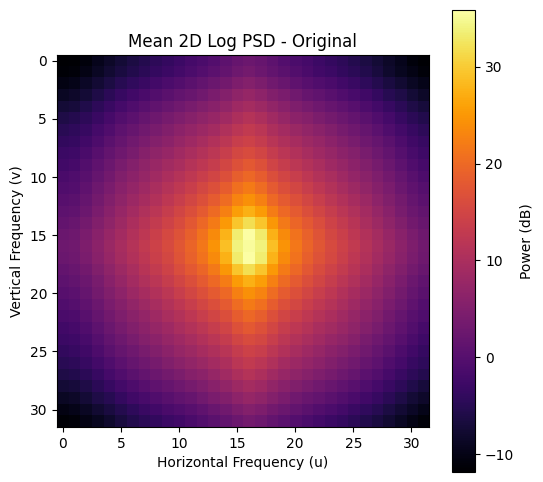

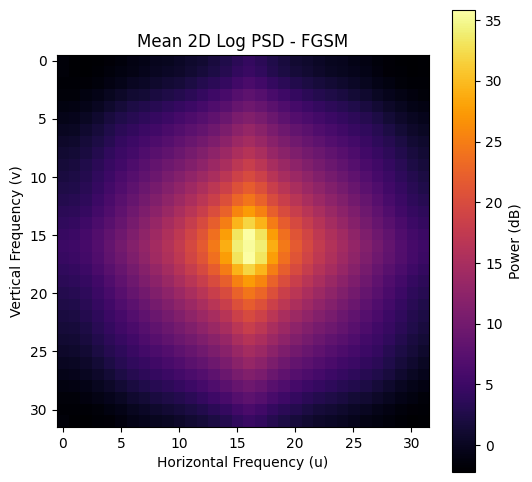

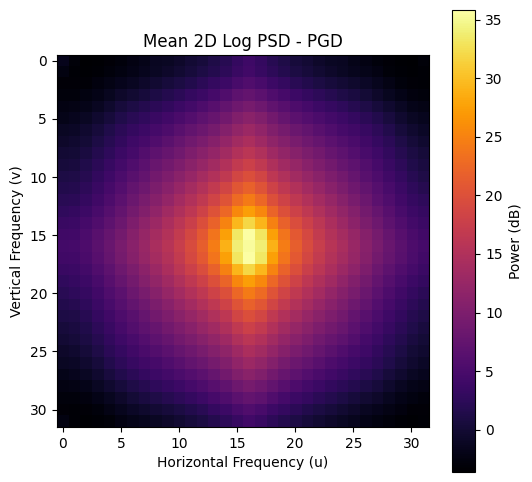

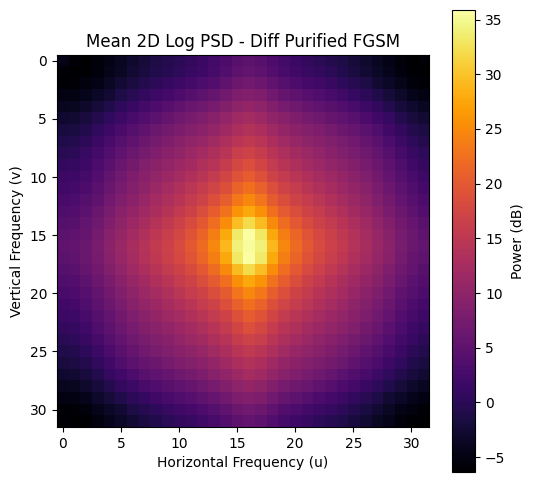

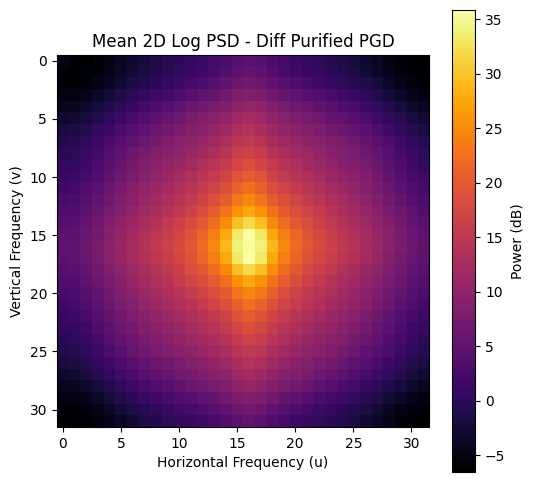

In [14]:
# Extract the underlying image tensors for plotting
original_images, _ = original_loader.dataset.tensors
fgsm_images, _ = fgsm_loader.dataset.tensors
pgd_images, _ = pgd_loader.dataset.tensors
diff_purified_fgsm_images, _ = diff_purified_fgsm_loader.dataset.tensors
diff_purified_pgd_images, _ = diff_purified_pgd_loader.dataset.tensors

# Instantiate the analyzer once
analyzer = SpectralAnalyzer(spatial_shape=(32, 32), device=device)

# Plot 2D heatmaps (automatically averages the whole batch)
analyzer.plot_2d(original_images, title="Mean 2D Log PSD - Original")
analyzer.plot_2d(fgsm_images, title="Mean 2D Log PSD - FGSM")
analyzer.plot_2d(pgd_images, title="Mean 2D Log PSD - PGD")
analyzer.plot_2d(diff_purified_fgsm_images, title="Mean 2D Log PSD - Diff Purified FGSM")
analyzer.plot_2d(diff_purified_pgd_images, title="Mean 2D Log PSD - Diff Purified PGD")

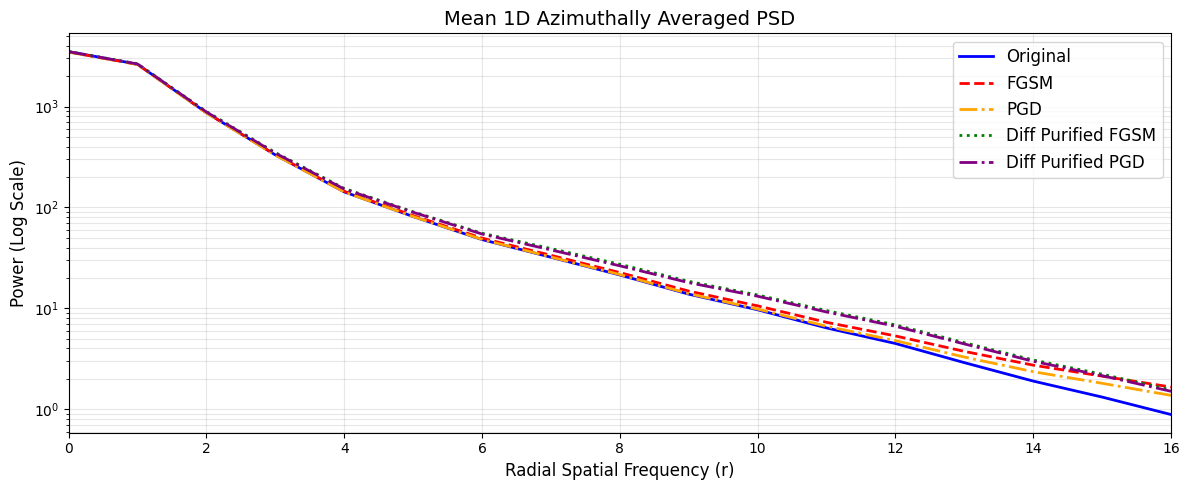

/Users/austinb.dev.bc/Projects/gap/src/gap/spectral.py:219: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(bottom=0, top=100)


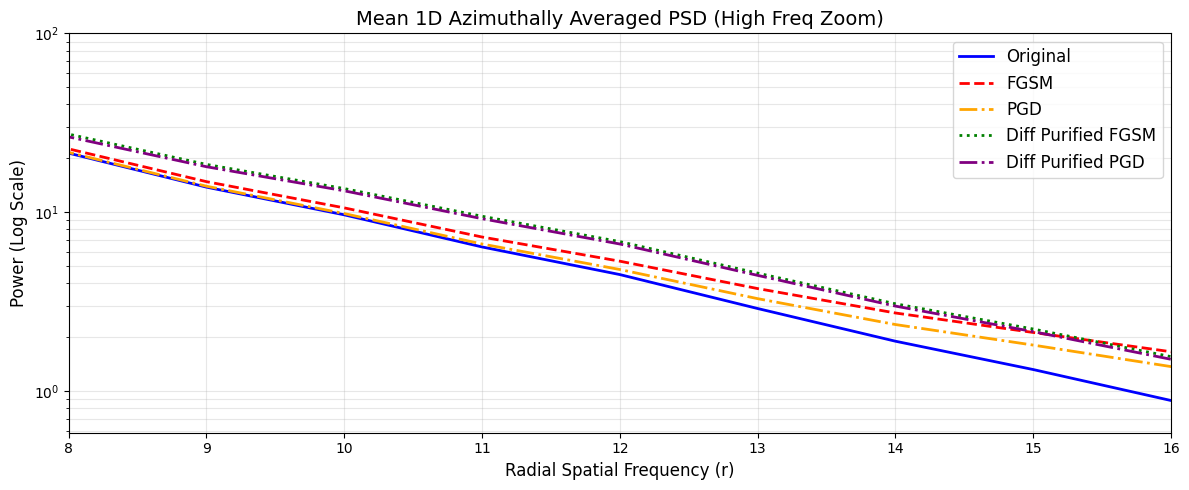

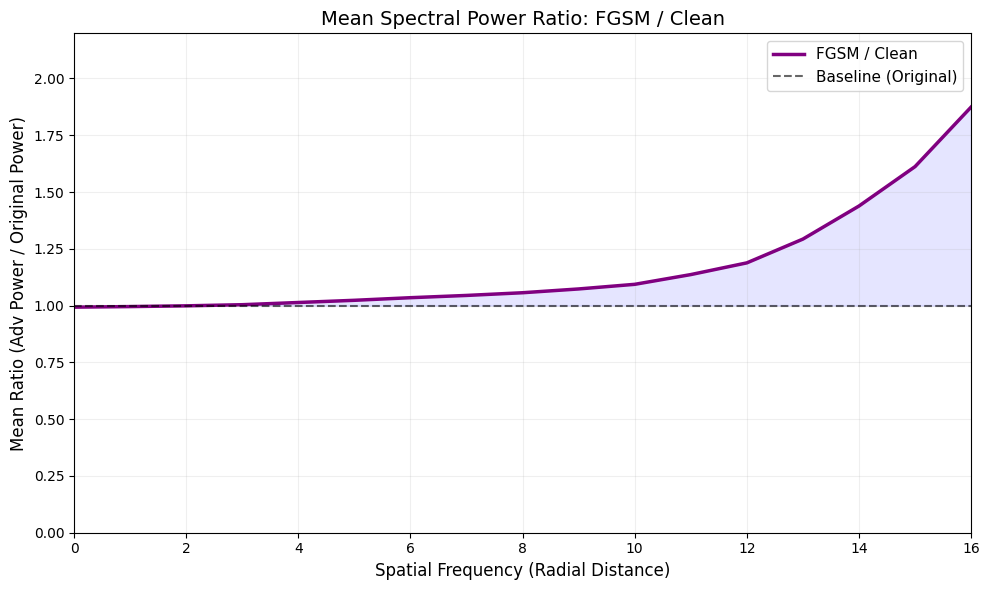

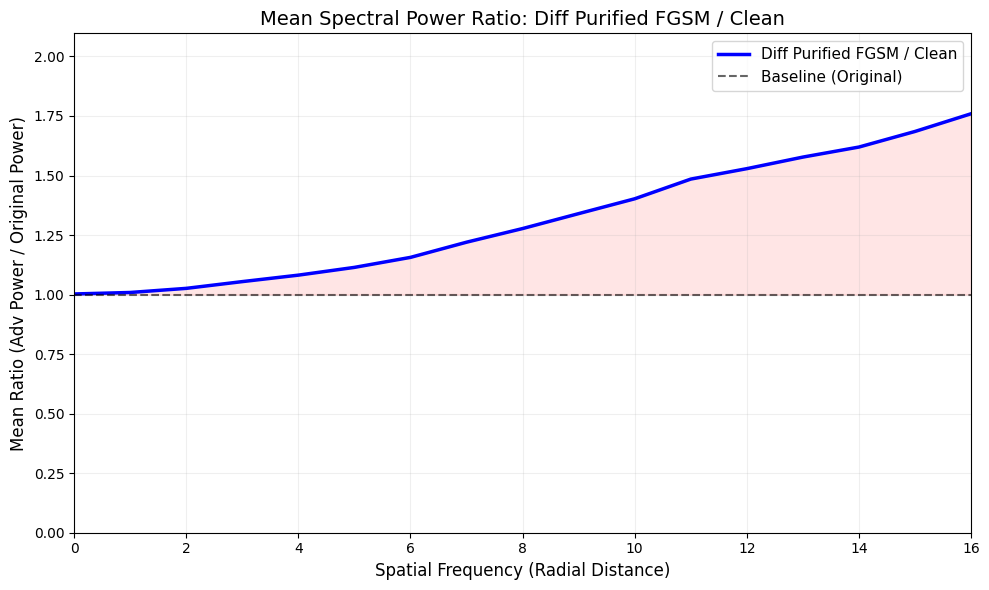

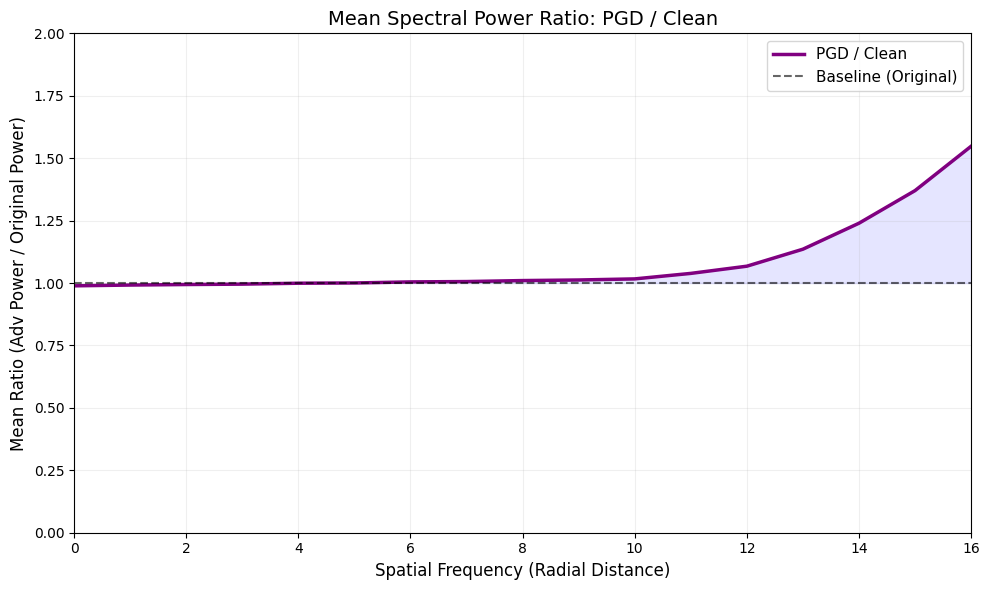

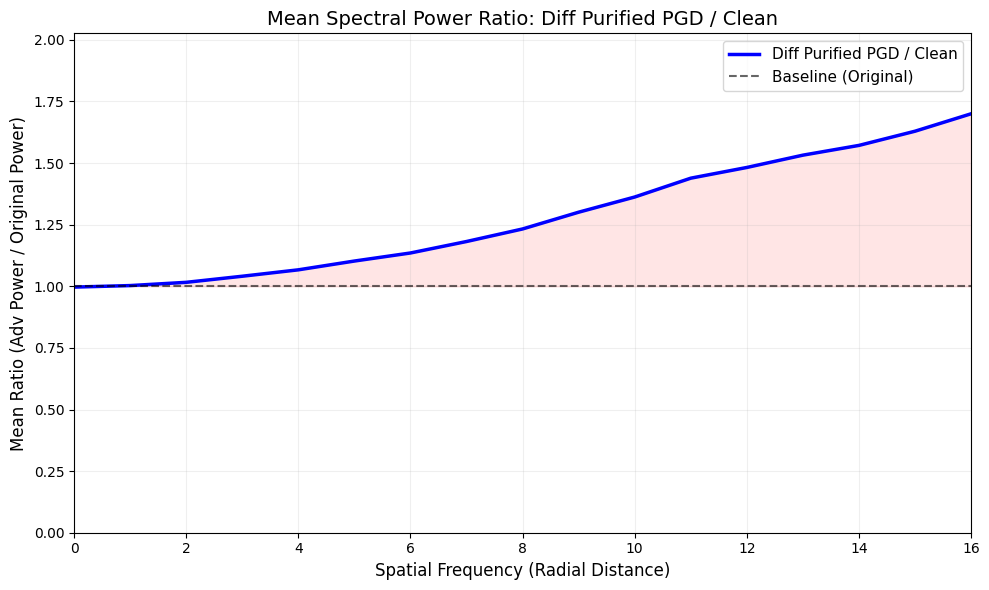

In [15]:
# Compare their 1D profiles on the same plot
image_label_dict = {"Original": original_images, "FGSM": fgsm_images, "PGD": pgd_images, "Diff Purified FGSM": diff_purified_fgsm_images, "Diff Purified PGD": diff_purified_pgd_images}
analyzer.plot_1d(image_label_dict)

# Compare their 1D profiles on the same plot
analyzer.plot_1d(
    image_label_dict, zoom_high_freq=True
)

analyzer.plot_1d_ratio(original_images, fgsm_images, diff_purified_fgsm_images, label_21="FGSM / Clean", label_31="Diff Purified FGSM / Clean")
analyzer.plot_1d_ratio(original_images, pgd_images, diff_purified_pgd_images, label_21="PGD / Clean", label_31="Diff Purified PGD / Clean")

Dataset    | Mean Low-Freq Power (dB) | Mean High-Freq Power (dB)
-------------------------------------------------------
Original   | 24.5933              | 6.3524              
FGSM       | 24.6507              | 7.4340              
PGD        | 24.5824              | 6.9483              
Diff Purified FGSM | 24.9303              | 8.1476              
Diff Purified PGD | 24.8710              | 8.0106              


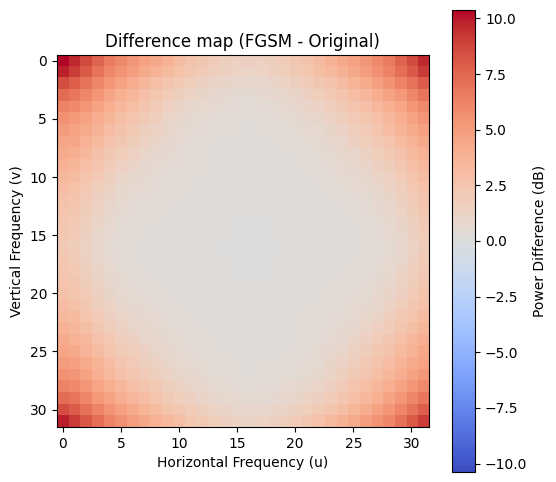

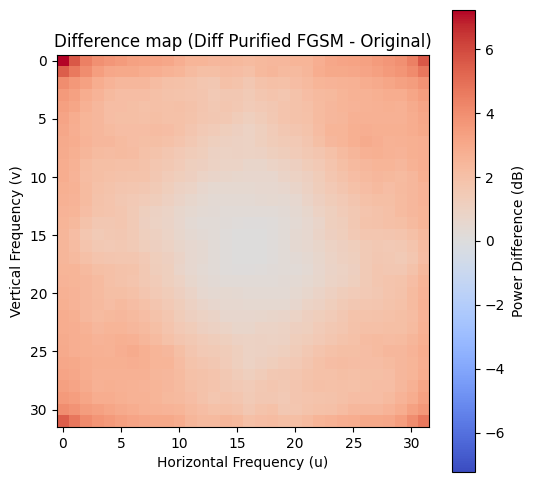

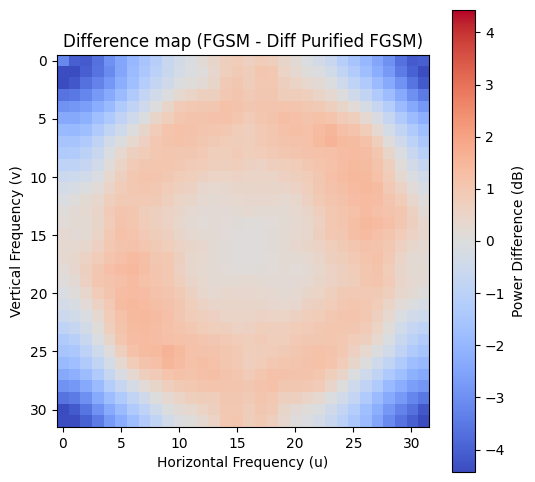

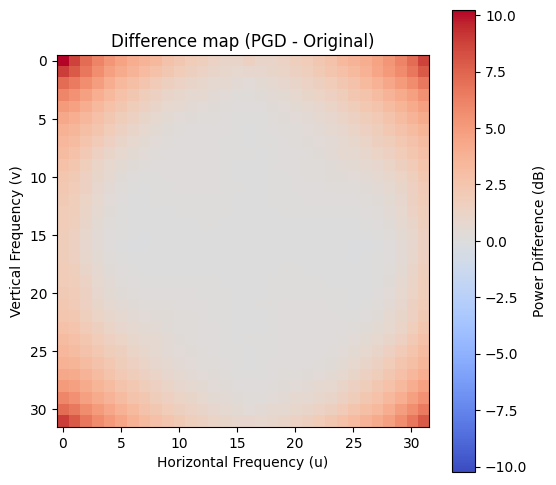

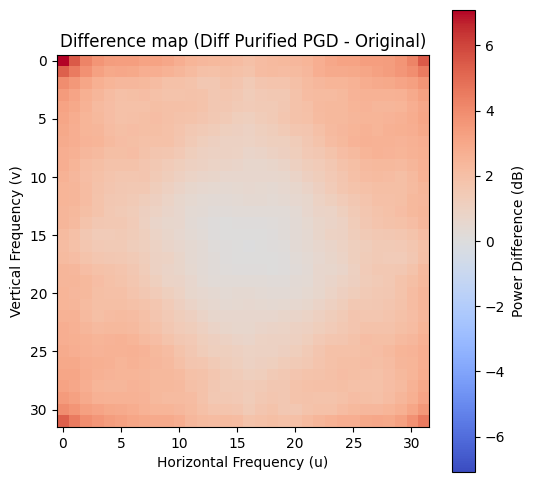

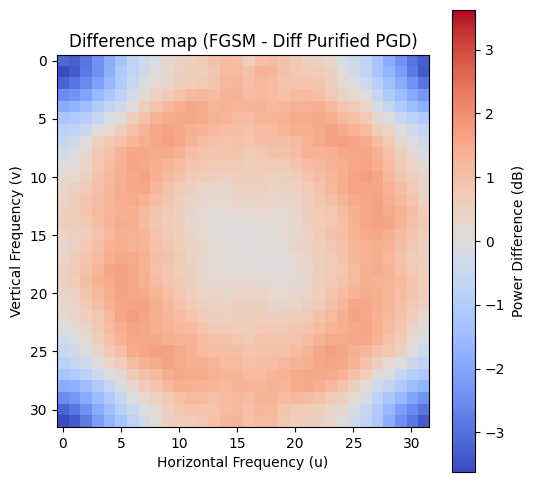

In [17]:
analyzer.print_spectral_stats(image_label_dict)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_2=fgsm_images,
    images_3=diff_purified_fgsm_images,
    title_21="Difference map (FGSM - Original)",
    title_31="Difference map (Diff Purified FGSM - Original)",
    title_32="Difference map (FGSM - Diff Purified FGSM)"
)

analyzer.plot_2d_difference(
    images_1=original_images,
    images_2=pgd_images,
    images_3=diff_purified_pgd_images,
    title_21="Difference map (PGD - Original)",
    title_31="Difference map (Diff Purified PGD - Original)",
    title_32="Difference map (FGSM - Diff Purified PGD)"
)
